# LOAD LIBRARIES

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [11]:
START_DATE, END_DATE = '2023-10-18', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [12]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.274 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-10-18 to 2024-08-21

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,1.492296,1.284265,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.900000,...,0.371742,-0.201140,-0.336475,0.617176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,817
2023-10-18 00:45:00,1.865617,0.908514,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.866667,...,0.473099,-0.073307,-0.363120,0.571588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,818
2023-10-18 01:15:00,1.949395,0.836877,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,...,0.448120,-0.095540,-0.332609,0.480687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,819
2023-10-18 01:45:00,1.794215,0.992058,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,...,0.334039,0.217531,-0.234399,0.239516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,820
2023-10-18 02:15:00,1.688259,1.105287,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.133333,...,0.299166,0.445909,-0.170026,0.292236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,4.180460,0.419748,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.142374,0.0,0.0,13.353333,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15644
2024-08-21 22:15:00,4.675844,-0.131424,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.066083,0.0,0.0,12.743333,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15645
2024-08-21 22:45:00,4.605323,-0.096441,1.691333,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.332683,0.0,0.0,12.346667,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,0.0,15646


# CLEAN DATA

In [13]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Remove id variable if ADD_ID==False
if ADD_ID==False:
    data.drop(columns='id', inplace=True)
    print('\nRemoved the record number variable (id)')
else:
    print('\nKeeping the record number variable (id)')

# Remove canopy variables if ADD_CANOPY==False
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height', 'cropN')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train

Filtered parcel_certainty=='certain': 4861/5510 rows kept

Keeping the treatment variable (trt)

Keeping the record number variable (id)

Dropped 6 canopy columns: ['can_height_parcelA', 'can_height_parcelB', 'cropN_parcelA', 'cropN_parcelB', 'can_height', 'cropN']

Dropped 18 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB']
Dropped 0 high-missing features (>5% NA) where target is not missing: []
Training rows (complete-case): 4861/4861


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,crop,timesince_soil_preparation,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,id,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 16:15:00,1.412933,1.018986,1.0,168.35800,0.0,7.300000,36,10.375064,11.346967,11.314175,45.215566,55.151191,43.047546,1.0,21.0,...,0.046801,-0.444220,0.167777,0.543725,0.460355,0.0,0.0,2.274546,1.037818,29.0,22.0,30.0,22.0,1809,0.324973
2023-11-07 17:15:00,2.510157,-0.122277,1.0,3.38364,0.5,6.600000,0,9.563013,11.195847,11.401140,45.038043,55.150493,43.385512,1.0,21.0,...,-0.103666,-0.431704,0.616304,0.924230,0.889783,0.0,0.0,2.263177,1.031258,29.0,22.0,30.0,22.0,1811,0.339963
2023-11-07 17:45:00,2.645646,-0.255572,1.0,0.00000,0.2,6.633333,0,9.168793,11.208270,11.384078,45.130002,55.166621,43.901626,1.0,21.0,...,-0.027894,-0.346287,1.127378,1.389628,1.462444,0.0,0.0,2.257514,1.027996,29.0,22.0,30.0,22.0,1812,-0.983566
2023-11-07 18:15:00,2.680843,-0.307616,1.0,0.00000,0.5,6.366667,0,9.184336,11.300447,11.183588,47.646389,55.322430,44.409653,1.0,21.0,...,0.133882,-0.150212,1.555405,1.858603,1.930903,0.0,0.0,2.251865,1.024747,29.0,22.0,30.0,22.0,1813,-0.064456
2023-11-07 18:45:00,2.589729,-0.227028,1.0,0.00000,0.0,6.200000,1,8.967710,11.269094,11.249196,49.572251,55.288503,45.100872,1.0,21.0,...,0.089865,-0.287557,2.341769,2.559854,2.970138,0.0,0.0,2.246230,1.021509,29.0,22.0,30.0,22.0,1814,0.066895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 15:15:00,-0.536841,5.836150,1.0,833.78400,0.0,21.536667,114,23.298518,20.930000,19.990000,30.527820,45.214621,42.548249,2.0,17.0,...,-0.972867,-1.664014,-0.261534,-0.312375,-0.314981,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15631,1.050287
2024-08-21 15:45:00,0.088506,5.221122,1.0,746.58600,0.0,21.616667,115,23.575185,21.082222,20.003703,30.320408,45.146085,42.520703,2.0,17.0,...,-1.028753,-1.698194,-0.283878,-0.344184,-0.290028,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15632,1.403125
2024-08-21 16:15:00,0.748269,4.547465,1.0,650.15200,0.0,21.413333,116,23.584075,21.230000,20.029999,30.092192,45.078119,42.512981,2.0,17.0,...,-1.085369,-1.706350,-0.275155,-0.311697,-0.262727,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15633,1.444844


# IMBALANCE HANDLING

## UNDER SAMPLING

In [14]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

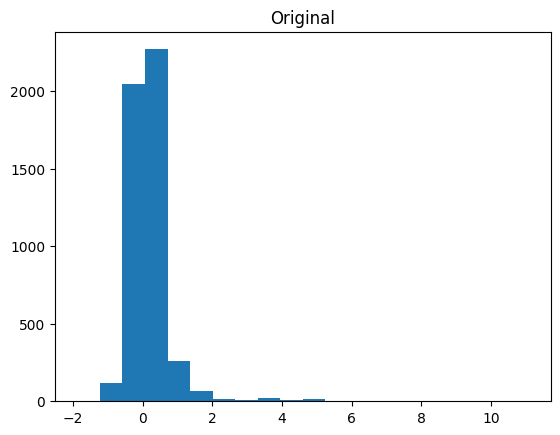

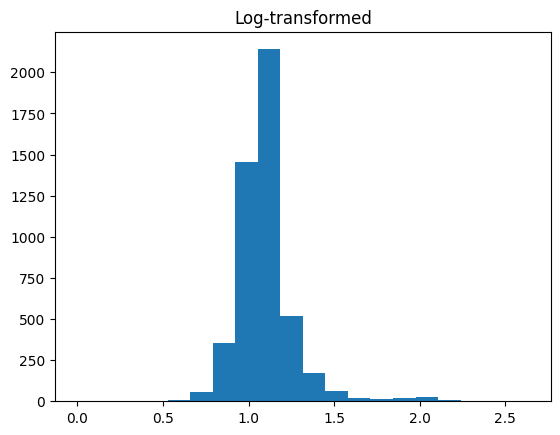

Applied log1p transform (shift=-1.869).


In [15]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


# CROSS-VAL SPLITS


Using block size of 5 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.101


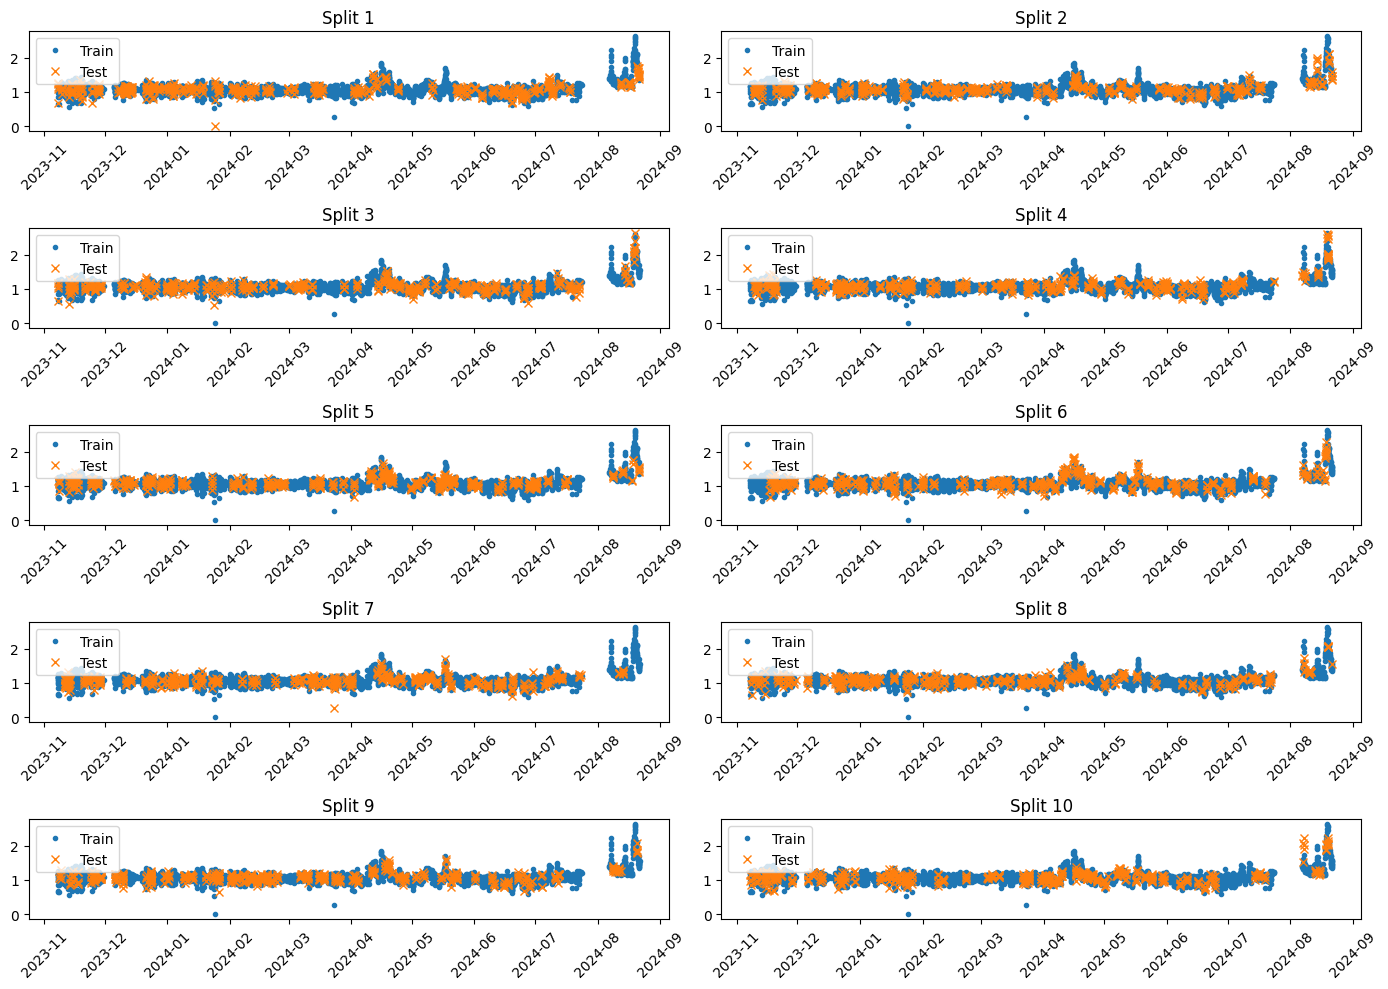

In [16]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6) # quantile 0.9 is a conservative choice
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [17]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Iter 1: kept=154 removed=['timesince_harvest', 'timesince_fert_org', 'trt', 'NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost', 'SW_IN_POT', 'prec', 'ta_lag9h', 'prec_lag9h', 'ta_lag6h_roll6hmean', 'prec_lag9h_roll3hsum'] RMSE_oof=0.3510 R2_oof=0.7841
Iter 2: kept=144 removed=['timesince_fert_min', 'prec_lag3h', 'ts_0.05_gfXG_lag3h', 'ts_0.05_gfXG_diff12h', 'ts_0.15_gfXG', 'ta_lag3h', 'ts_0.05_gfXG_lag6h', 'ta_lag3h_roll3hmean', 'ts_0.15_gfXG_diff12h', 'ts_0.05_gfXG_lag6h_roll9hmean'] RMSE_oof=0.3440 R2_oof=0.7925
Iter 3: kept=134 removed=['ta_lag6h_roll3hmean', 'ts_0.05_gfXG_roll9hmean', 'ta_lag6h_roll9hmean', 'ta_lag6h', 'ts_0.05_gfXG_lag9h', 'ts_0.15_gfXG_diff24h', 'prec_lag9h_roll9hsum', 'ts_0.05_gfXG_lag9h_roll6hmean', 'wfps_0.15_gfXG_lag3h', 'ts_0.15_gfXG_lag9h'] RMSE_oof=0.3446 R2_oof=0.7918
Iter 4: kept=124 removed=['ts_0.05_gfXG_lag3h_roll9hmean', 'wfps_0.05_gfXG_lag9h', 'prec_lag6h', 'ta_lag9h_roll3hmean', 'ts_0.15_gfXG_lag6h', 'ts_0.15_gfXG_lag3h_roll3hmean', 'ts_0.05_gfXG_diff24h', 

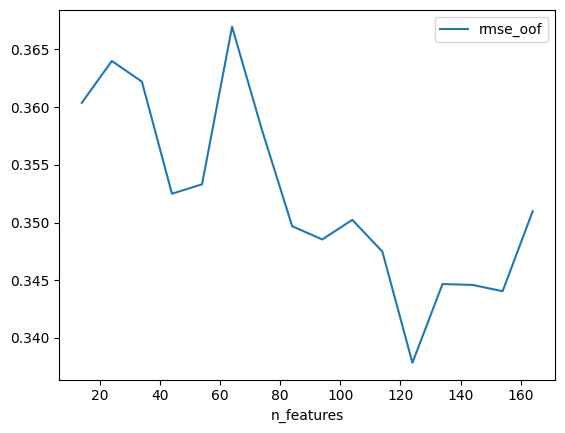

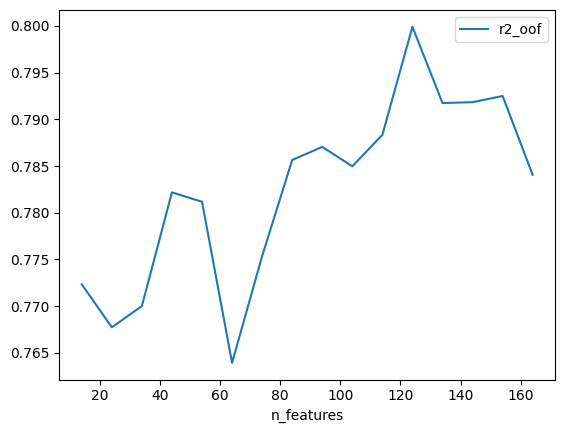

In [18]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=10,           # try 5 or 10 if it’s slow
    min_features=10,
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

# optional plot in notebook
hist.plot(x="n_features", y="rmse_oof");
hist.plot(x="n_features", y="r2_oof");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")


# EXPORT 

In [19]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_FN2O_XGBoost.txt
Wrote: ranked_features_FN2O_XGBoost.txt


# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-02-24 14:19:57
